# HMDCNN для CIFAR-10, EMNIST, SVHN
Компактная реализация подхода из статьи: DCNN-модули, подбор числа conv-слоев по `DeltaEG`, MSL, сигмоидальная близость классов, кластеры и рекурсивные дочерние модули.

In [7]:
%pip install torch torchvision numpy matplotlib thop

In [21]:
import math
from tqdm import tqdm
import random
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, TensorDataset
import pickle
import dill

try:
    from thop import profile
except ImportError:
    profile = None
    print("thop not installed. Install with: pip install thop")

warnings.filterwarnings("ignore")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

thop not installed. Install with: pip install thop
device: cuda


In [2]:
class DCNNModule(nn.Module):
    def __init__(self, conv_layers: int, in_channels: int, input_size: int, num_classes: int, pool_out: int = 4):
        super().__init__()
        blocks, channels = [], in_channels
        for i in range(conv_layers):
            out_channels = min(32 * (2 ** i), 512)
            blocks += [nn.Conv2d(channels, out_channels, 3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)]
            if i < conv_layers - 1 and input_size > 1:
                blocks.append(nn.MaxPool2d(2))
                input_size //= 2
            channels = out_channels
        self.features = nn.Sequential(*blocks)
        self.output_channels = channels
        self.output_size = input_size
        self.pool = nn.AdaptiveAvgPool2d((min(pool_out, input_size), min(pool_out, input_size)))
        fc_in = channels * min(pool_out, input_size) ** 2
        self.classifier = nn.Sequential(
            nn.Linear(fc_in, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor, return_features: bool = False):
        fmap = self.features(x)
        logits = self.classifier(torch.flatten(self.pool(fmap), 1))
        return (logits, fmap) if return_features else logits


def model_size_kb(model: nn.Module) -> float:
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1024


def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3,
                device=device, return_history=False,
                progress=False, print_every=15):
    model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    best_acc, best_state = 0.0, None
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": [],
    }

    epoch_iter = tqdm(range(1, epochs + 1), desc="Training", leave=True) if progress else range(1, epochs + 1)

    for epoch in epoch_iter:
        model.train()
        loss_sum = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = loss_sum / max(total, 1)
        train_acc = correct / max(total, 1)
        val_acc = evaluate_loader(model, val_loader, device)
        lr_now = opt.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr_now)

        if progress:
            epoch_iter.set_postfix({
                "loss": f"{train_loss:.4f}",
                "train_acc": f"{100 * train_acc:.1f}%",
                "val_acc": f"{100 * val_acc:.1f}%"
            })

        if progress and (epoch % print_every == 0 or epoch == epochs):
            print(
                f"          Epoch {epoch}: "
                f"Train Acc: {100 * train_acc:.1f}%, "
                f"Val Acc: {100 * val_acc:.1f}%, "
                f"LR: {lr_now:.6f}"
            )

        if val_acc >= best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return (best_acc, history) if return_history else best_acc


def evaluate_loader(model, loader, device=device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            pred = model(x.to(device)).argmax(1).cpu()
            correct += (pred == y).sum().item()
            total += y.numel()
    return correct / max(total, 1)


def compute_msl(model, loader, num_classes: int, device=device):
    model.eval()
    sums = torch.zeros(num_classes, num_classes)
    counts = torch.zeros(num_classes)
    with torch.no_grad():
        for x, y in loader:
            p = torch.softmax(model(x.to(device)), dim=1).cpu()
            for cls in range(num_classes):
                mask = (y == cls)
                if mask.any():
                    sums[cls] += p[mask].sum(0)
                    counts[cls] += mask.sum()
    return (sums / counts.clamp_min(1).unsqueeze(1)).numpy()


def sigmoid_similarity(msl: np.ndarray):
    m = msl.shape[0]
    sim = 1 / (1 + np.exp(np.clip(-10 * m * (msl - 1 / m), -80, 80)))
    np.fill_diagonal(sim, 1.0)
    return sim


def super_clusters(sim: np.ndarray, threshold: float = 0.5):
    unused, clusters = set(range(sim.shape[0])), []
    while unused:
        cluster = {min(unused)}
        changed = True
        while changed:
            changed = False
            for j in list(unused - cluster):
                if any(sim[i, j] >= threshold or sim[j, i] >= threshold for i in cluster):
                    cluster.add(j)
                    changed = True
        clusters.append(sorted(cluster))
        unused -= cluster
    return clusters


def choose_conv_layers(in_channels, input_size, num_classes, train_loader, val_loader,
                       max_layers=5, selection_epochs=2, tau=1e-4, device=device):
    max_layers = max(1, min(max_layers, int(math.log2(max(input_size, 1))) + 1))
    prev_acc = prev_size = None
    best = (1, -1.0)
    for layers in range(1, max_layers + 1):
        model = DCNNModule(layers, in_channels, input_size, num_classes)
        print(f"        Testing {layers} conv layer(s)...")

        acc = train_model(
            model,
            train_loader,
            val_loader,
            epochs=selection_epochs,
            device=device,
            progress=False
        )
        acc_pct = 100.0 * acc
        size = model_size_kb(model)

        print(f"          Acc: {acc_pct:.2f}%, Size: {size:.2f} KB")
        size = model_size_kb(model)
        if acc > best[1]:
            best = (layers, acc)
        if prev_acc is not None and size > prev_size:
            delta_eg = (acc - prev_acc) / (size - prev_size)
            if delta_eg < tau:
                return max(1, layers - 1)
        prev_acc, prev_size = acc, size
    return best[0]

In [3]:
class ClassRemapDataset(Dataset):
    def __init__(self, base: Dataset, indices: Sequence[int], label_map: Dict[int, int]):
        self.base, self.indices, self.label_map = base, list(indices), label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base[self.indices[i]]
        return x, self.label_map[int(y)]


def dataset_targets(ds):
    targets = getattr(ds, "targets", None)
    if targets is None:
        targets = getattr(ds, "labels", None)
    return np.asarray(targets, dtype=int)


def stratified_indices(ds, class_ids, train_per_class=None, val_per_class=200, val_size=None, seed=42):
    rng = np.random.default_rng(seed)
    targets = dataset_targets(ds)
    train_idx, val_idx = [], []

    if val_size is not None:
        all_idx = np.where(np.isin(targets, class_ids))[0]
        rng.shuffle(all_idx)
        val_idx = all_idx[:val_size].tolist()
        train_idx = all_idx[val_size:].tolist()
        if train_per_class is not None:
            selected = []
            train_targets = targets[train_idx]
            for cls in class_ids:
                cls_idx = np.array(train_idx)[train_targets == cls]
                selected.extend(cls_idx[:train_per_class].tolist())
            train_idx = selected
        rng.shuffle(train_idx)
        return train_idx, val_idx

    for cls in class_ids:
        idx = np.where(targets == cls)[0]
        rng.shuffle(idx)
        val_idx.extend(idx[:val_per_class].tolist())
        rest = idx[val_per_class:]
        if train_per_class is not None:
            rest = rest[:train_per_class]
        train_idx.extend(rest.tolist())
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


def make_loaders(base_train, class_ids, batch_size=128, train_per_class=None, val_per_class=200, val_size=None):
    label_map = {cls: i for i, cls in enumerate(class_ids)}
    train_idx, val_idx = stratified_indices(base_train, class_ids, train_per_class, val_per_class, val_size)
    train_ds = ClassRemapDataset(base_train, train_idx, label_map)
    val_ds = ClassRemapDataset(base_train, val_idx, label_map)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0),
            DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0),
            train_ds, val_ds)


def class_name_map(ds, class_ids):
    names = getattr(ds, "classes", None)
    return {int(c): str(names[int(c)]) if names is not None and int(c) < len(names) else str(c) for c in class_ids}


def load_dataset(name: str, root="./data", emnist_split="balanced"):
    name = name.lower()
    if name == "cifar10":
        tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
        train = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=tfm)
        test = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=tfm)
    elif name == "svhn":
        tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970))])
        train = torchvision.datasets.SVHN(root=root, split="train", download=True, transform=tfm)
        test = torchvision.datasets.SVHN(root=root, split="test", download=True, transform=tfm)
    elif name == "emnist":
        tfm = transforms.Compose([
            transforms.Lambda(lambda img: TF.hflip(TF.rotate(img, -90))),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
        train = torchvision.datasets.EMNIST(root=root, split=emnist_split, train=True, download=True, transform=tfm)
        test = torchvision.datasets.EMNIST(root=root, split=emnist_split, train=False, download=True, transform=tfm)
    else:
        raise ValueError("name must be: cifar10, emnist, svhn")
    class_ids = sorted(np.unique(dataset_targets(train)).astype(int).tolist())
    return train, test, class_ids, class_name_map(train, class_ids)

In [ ]:
@dataclass
class Node:
    node_id: str
    classes: List[int]
    level: int
    module: Optional[DCNNModule] = None
    children: List["Node"] = field(default_factory=list)


class HMDCNN(nn.Module):
    def __init__(self, class_names: Dict[int, str], max_depth=2, max_layers=5, epochs=5,
                 selection_epochs=2, batch_size=128, tau=1e-4, sim_threshold=0.5, min_child_samples=20):
        super().__init__()
        self.class_names = class_names
        self.max_depth = max_depth
        self.max_layers = max_layers
        self.epochs = epochs
        self.selection_epochs = selection_epochs
        self.batch_size = batch_size
        self.tau = tau
        self.sim_threshold = sim_threshold
        self.min_child_samples = min_child_samples
        self.root = None
        self.histories = {}
        self.summary = {}

    def fit(self, train_ds: Dataset, val_ds: Dataset, class_ids: List[int]):
        x0, _ = train_ds[0]
        self.root = Node("root", list(class_ids), 0)
        self._fit_node(self.root, train_ds, val_ds, x0.shape[0], x0.shape[-1])
        return self

    def _loader(self, ds, shuffle):
        return DataLoader(ds, batch_size=self.batch_size, shuffle=shuffle, num_workers=0)

    def _fit_node(self, node, train_ds, val_ds, in_channels, input_size):
        if len(node.classes) <= 1:
            return
        train_loader, val_loader = self._loader(train_ds, True), self._loader(val_ds, False)
        layers = choose_conv_layers(in_channels, input_size, len(node.classes), train_loader, val_loader,
                                    self.max_layers, self.selection_epochs, self.tau)
        node.module = DCNNModule(layers, in_channels, input_size, len(node.classes))
        print(f"    Step 4: Training for {self.epochs} epochs...")

        acc, history = train_model(
            node.module,
            train_loader,
            val_loader,
            epochs=self.epochs,
            device=device,
            return_history=True,
            progress=True,
            print_every=15
        )
        history.update({"classes": len(node.classes), "conv_layers": layers, "best_val_acc": acc})
        self.histories[node.node_id] = history
        print(f"{node.node_id}: classes={len(node.classes)}, conv={layers}, val_acc={acc:.3f}")

        if node.level >= self.max_depth:
            return
        sim = sigmoid_similarity(compute_msl(node.module, train_loader, len(node.classes), device))
        clusters = [c for c in super_clusters(sim, self.sim_threshold) if len(c) < len(node.classes)]
        if not clusters:
            return
        for i, cluster in enumerate(clusters):
            child_train = self._feature_dataset(node.module, train_ds, cluster)
            child_val = self._feature_dataset(node.module, val_ds, cluster)
            if len(child_train) < self.min_child_samples or len(child_val) == 0:
                continue
            child = Node(f"{node.node_id}.{i}", [node.classes[j] for j in cluster], node.level + 1)
            node.children.append(child)
            self._fit_node(child, child_train, child_val, node.module.output_channels, node.module.output_size)

    def _feature_dataset(self, module, ds, parent_local_classes):
        module.eval()
        local_map = {parent_cls: i for i, parent_cls in enumerate(parent_local_classes)}
        xs, ys = [], []
        loader = DataLoader(ds, batch_size=self.batch_size, shuffle=False, num_workers=0)
        with torch.no_grad():
            for x, y in loader:
                keep = torch.tensor([int(v) in local_map for v in y])
                if keep.any():
                    _, fmap = module(x[keep].to(device), return_features=True)
                    xs.append(fmap.cpu())
                    ys += [local_map[int(v)] for v in y[keep]]
        if not xs:
            return TensorDataset(torch.empty(0), torch.empty(0, dtype=torch.long))
        return TensorDataset(torch.cat(xs), torch.tensor(ys, dtype=torch.long))

    def predict_one(self, x):
        node = self.root
        current = x.unsqueeze(0).to(device)
        while node and node.module:
            node.module.eval()
            with torch.no_grad():
                logits, fmap = node.module(current, return_features=True)
                local_pred = int(logits.argmax(1).item())
            global_pred = node.classes[local_pred]
            next_node = next((ch for ch in node.children if global_pred in ch.classes), None)
            if next_node is None:
                return global_pred
            current, node = fmap, next_node
        return node.classes[0]

    def evaluate(self, base_test, class_ids, limit_per_class=200):
        targets = dataset_targets(base_test)
        rng = np.random.default_rng(42)
        indices = []
        for cls in class_ids:
            idx = np.where(targets == cls)[0]
            rng.shuffle(idx)
            indices.extend(idx[:limit_per_class].tolist())
        correct = 0
        for idx in indices:
            x, y = base_test[idx]
            correct += int(self.predict_one(x) == int(y))
        return correct / max(len(indices), 1)

    def node_count(self, node=None):
        node = self.root if node is None else node
        if node is None:
            return 0
        return 1 + sum(self.node_count(child) for child in node.children)

    def print_tree(self, node=None, indent=""):
        node = self.root if node is None else node
        names = [self.class_names[c] for c in node.classes[:6]]
        print(f"{indent}{node.node_id}: {len(node.classes)} classes {names}{'...' if len(node.classes) > 6 else ''}")
        for child in node.children:
            self.print_tree(child, indent + "  ")

    def get_all_modules(self) -> List[nn.Module]:
        modules = []
        def collect(node):
            if node.module is not None:
                modules.append(node.module)
            for child in node.children:
                collect(child)
        if self.root is not None:
            collect(self.root)
        return modules

    def total_parameters(self) -> int:
        return sum(sum(p.numel() for p in m.parameters()) for m in self.get_all_modules())

    def total_buffers(self) -> int:
        return sum(sum(b.numel() for b in m.buffers()) for m in self.get_all_modules())

    def model_size_mb(self) -> float:
        param_bytes = sum(p.numel() * p.element_size() for p in self.parameters())
        buffer_bytes = sum(b.numel() * b.element_size() for b in self.buffers())
        return (param_bytes + buffer_bytes) / (1024 ** 2)

    def parameters(self):
        for module in self.get_all_modules():
            for param in module.parameters():
                yield param

    def buffers(self):
        for module in self.get_all_modules():
            for buf in module.buffers():
                yield buf

    def compute_mmac(self, input_shape: tuple = (1, 3, 32, 32), device=None) -> float:
        try:
            from thop import profile
        except ImportError:
            print("thop not available. Install with: pip install thop")
            return float("nan")

        if device is None:
            device = next(self.parameters()).device if list(self.parameters()) else torch.device('cpu')

        self.eval()
        dummy = torch.randn(*input_shape, device=device)

        with torch.no_grad():
            macs, _ = profile(self.forward_for_profile, inputs=(dummy,), verbose=False)

        return macs / 1e6

    def forward_for_profile(self, x):
        node = self.root
        current = x
        while node and node.module:
            node.module.eval()
            logits, fmap = node.module(current, return_features=True)
            local_pred = int(logits.argmax(1).item())
            global_pred = node.classes[local_pred]
            next_node = next((ch for ch in node.children if global_pred in ch.classes), None)
            if next_node is None:
                return logits
            current, node = fmap, next_node
        if node and node.classes:
            return torch.zeros(1, len(node.classes), device=x.device)
        return torch.zeros(1, 1, device=x.device)

    def get_summary_dict(self) -> dict:
        size_mb = self.model_size_mb()
        mmac = self.compute_mmac_alternative()

        return {
            "nodes": self.node_count(),
            "total_parameters": self.total_parameters(),
            "size_mb": size_mb,
            "mmac": mmac,
            "root_val_acc": self.histories.get("root", {}).get("best_val_acc", np.nan),
        }

In [5]:
def run_experiment(name, train_per_class=None, val_per_class=200, val_size=None, test_per_class=None,
                   epochs=5, selection_epochs=2, max_depth=2, batch_size=128,
                   emnist_split="balanced"):
    train_base, test_base, class_ids, names = load_dataset(name, emnist_split=emnist_split)
    _, _, train_ds, val_ds = make_loaders(
        train_base, class_ids, batch_size=batch_size,
        train_per_class=train_per_class, val_per_class=val_per_class, val_size=val_size
    )
    model = HMDCNN(names, max_depth=max_depth, epochs=epochs,
                  selection_epochs=selection_epochs, batch_size=batch_size)
    model.fit(train_ds, val_ds, class_ids)
    model.print_tree()

    # Compute model metrics
    total_params = model.total_parameters()
    model_size_mb = model.model_size_mb()

    # Get input shape based on dataset
    sample_x, _ = train_base[0]
    input_shape = (1, sample_x.shape[0], sample_x.shape[1], sample_x.shape[2])

    mmac = model.compute_mmac(input_shape=input_shape, device=device)

    acc = model.evaluate(test_base, class_ids, limit_per_class=test_per_class or 10**9)

    model.summary = {
        "dataset": name.upper(),
        "test_acc": acc,
        "test_error": 100 - acc * 100,
        "nodes": model.node_count(),
        "total_params": total_params,
        "size_mb": model_size_mb,
        "mmac": mmac,
        "root_val_acc": model.histories.get("root", {}).get("best_val_acc", np.nan),
    }

    print(f"{name.upper()} test accuracy: {acc:.3f}")
    print(f"{name.upper()} test error: {(1 - acc) * 100:.2f}%")
    print(f"{name.upper()} model size: {model_size_mb:.2f} MB")
    print(f"{name.upper()} MMac: {mmac:.2f}")
    return model

def plot_training_curves(model, max_nodes=6):
    items = list(model.histories.items())[:max_nodes]
    if not items:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for node_id, h in items:
        epochs = range(1, len(h["train_loss"]) + 1)
        label = f"{node_id} ({h['classes']} cls, {h['conv_layers']} conv)"
        axes[0].plot(epochs, h["train_loss"], marker="o", label=label)
        axes[1].plot(epochs, h["val_acc"], marker="o", label=label)
    axes[0].set_title("Train loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[1].set_title("Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_metric_comparison(models):
    rows = [m.summary for m in models if getattr(m, "summary", None)]
    if not rows:
        return
    names = [r["dataset"] for r in rows]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    metrics = [("test_acc", "Test accuracy"), ("root_val_acc", "Root validation accuracy"), ("nodes", "Tree nodes")]
    for ax, (key, title) in zip(axes, metrics):
        values = [r[key] for r in rows]
        ax.bar(names, values)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.3)
        if "acc" in key:
            ax.set_ylim(0, 1)
            for i, v in enumerate(values):
                ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
        else:
            for i, v in enumerate(values):
                ax.text(i, v, str(v), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


In [ ]:
def compute_mmac_from_loaded_model(model, input_shape):
    total_macs = 0

    def count_conv2d_macs(conv_layer, input_h, input_w, in_c):
        out_h = (input_h + 2 * conv_layer.padding[0] - conv_layer.kernel_size[0]) // conv_layer.stride[0] + 1
        out_w = (input_w + 2 * conv_layer.padding[1] - conv_layer.kernel_size[1]) // conv_layer.stride[1] + 1
        macs = out_h * out_w * in_c * conv_layer.out_channels * conv_layer.kernel_size[0] * conv_layer.kernel_size[1]
        return macs, (out_h, out_w, conv_layer.out_channels)

    def count_linear_macs(linear_layer, in_features):
        return in_features * linear_layer.out_features, linear_layer.out_features

    def process_module(module, in_h, in_w, in_c):
        macs = 0
        h, w, c = in_h, in_w, in_c

        for layer in module.features:
            if isinstance(layer, nn.Conv2d):
                layer_macs, (h, w, c) = count_conv2d_macs(layer, h, w, c)
                macs += layer_macs
            elif isinstance(layer, nn.MaxPool2d):
                h = h // layer.kernel_size
                w = w // layer.kernel_size

        flat_size = c * h * w
        for layer in module.classifier:
            if isinstance(layer, nn.Linear):
                layer_macs, flat_size = count_linear_macs(layer, flat_size)
                macs += layer_macs

        return macs, (h, w, c)

    def traverse(node, in_h, in_w, in_c):
        if node.module is None or len(node.classes) <= 1:
            return 0

        macs, (out_h, out_w, out_c) = process_module(node.module, in_h, in_w, in_c)
        total = macs

        for child in node.children:
            total += traverse(child, out_h, out_w, out_c)

        return total

    _, in_c, in_h, in_w = input_shape
    total_macs = traverse(model.root, in_h, in_w, in_c)
    return total_macs / 1e6

100%|██████████| 170M/170M [00:05<00:00, 30.3MB/s]


        Testing 1 conv layer(s)...
          Acc: 69.24%, Size: 526.79 KB
        Testing 2 conv layer(s)...
          Acc: 77.54%, Size: 1111.54 KB
        Testing 3 conv layer(s)...
          Acc: 80.60%, Size: 2425.04 KB
    Step 4: Training for 150 epochs...


Training:  10%|█         | 15/150 [03:45<34:14, 15.21s/it, loss=0.5959, train_acc=78.8%, val_acc=76.4%]

          Epoch 15: Train Acc: 78.8%, Val Acc: 76.4%, LR: 0.001000


Training:  20%|██        | 30/150 [07:30<29:42, 14.86s/it, loss=0.4112, train_acc=85.3%, val_acc=77.2%]

...

          Epoch 120: Train Acc: 99.2%, Val Acc: 79.6%, LR: 0.001000


Training:  90%|█████████ | 135/150 [01:11<00:08,  1.85it/s, loss=0.0083, train_acc=99.7%, val_acc=81.4%]

          Epoch 135: Train Acc: 99.7%, Val Acc: 81.4%, LR: 0.001000


Training: 100%|██████████| 150/150 [01:19<00:00,  1.88it/s, loss=0.0028, train_acc=99.9%, val_acc=81.4%]


          Epoch 150: Train Acc: 99.9%, Val Acc: 81.4%, LR: 0.001000
root.3: classes=2, conv=1, val_acc=0.824
root: 10 classes ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog']...
  root.0: 1 classes ['airplane']
  root.1: 1 classes ['automobile']
  root.2: 1 classes ['bird']
  root.3: 2 classes ['cat', 'dog']
    root.3.0: 1 classes ['cat']
    root.3.1: 1 classes ['dog']
  root.4: 1 classes ['deer']
  root.5: 1 classes ['frog']
  root.6: 1 classes ['horse']
  root.7: 1 classes ['ship']
  root.8: 1 classes ['truck']
thop not available. Install with: pip install thop
CIFAR10 test accuracy: 0.791
CIFAR10 test error: 20.90%
CIFAR10 model size: 1.66 MB
CIFAR10 MMac: nan


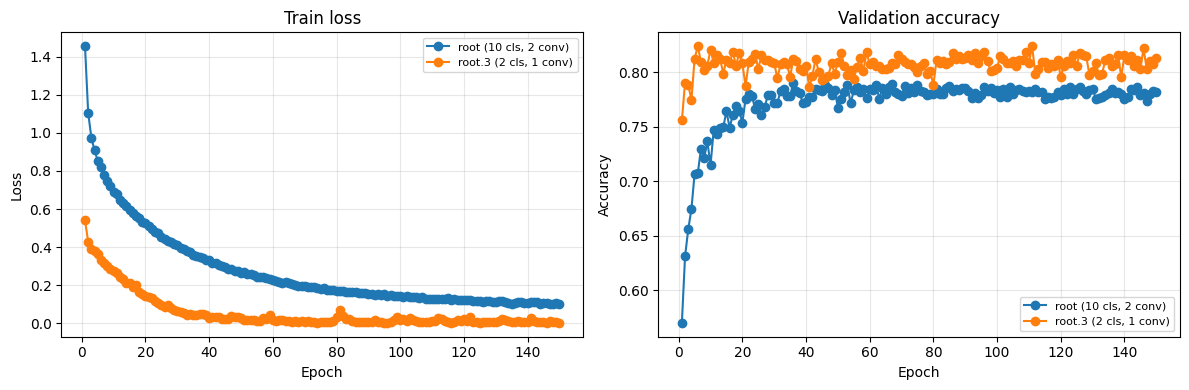

In [26]:
# CIFAR-10
cifar_model = run_experiment("cifar10", val_size=5000, test_per_class=None,
                             epochs=150, selection_epochs=20, max_depth=10, batch_size=200)
plot_training_curves(cifar_model)

In [27]:
cifar_mmac = compute_mmac_from_loaded_model(cifar_model, (1, 3, 32, 32))
cifar_model.summary['mmac'] = cifar_mmac

with open("cifar_model.pkl", "wb") as f:
    dill.dump(cifar_model, f)

print("CIFAR-10:")
print(f"MMac: {cifar_mmac:.2f}")

CIFAR-10:
MMac: 16.62


100%|██████████| 562M/562M [00:04<00:00, 114MB/s]


        Testing 1 conv layer(s)...
          Acc: 86.22%, Size: 561.68 KB
        Testing 2 conv layer(s)...
          Acc: 88.44%, Size: 1146.43 KB
    Step 4: Training for 150 epochs...


Training:  10%|█         | 15/150 [07:13<1:05:56, 29.31s/it, loss=0.4946, train_acc=83.3%, val_acc=85.1%]

          Epoch 15: Train Acc: 83.3%, Val Acc: 85.1%, LR: 0.001000


Training:  20%|██        | 30/150 [14:30<57:56, 28.97s/it, loss=0.4388, train_acc=84.9%, val_acc=85.6%]

...

          Epoch 120: Train Acc: 99.8%, Val Acc: 97.8%, LR: 0.001000


Training:  90%|█████████ | 135/150 [00:50<00:05,  2.75it/s, loss=0.0072, train_acc=99.8%, val_acc=98.2%]

          Epoch 135: Train Acc: 99.8%, Val Acc: 98.2%, LR: 0.001000


Training: 100%|██████████| 150/150 [00:56<00:00,  2.67it/s, loss=0.0051, train_acc=99.9%, val_acc=98.7%]


          Epoch 150: Train Acc: 99.9%, Val Acc: 98.7%, LR: 0.001000
root.16: classes=2, conv=1, val_acc=0.987
root: 47 classes ['0', '1', '2', '3', '4', '5']...
  root.0: 3 classes ['0', 'D', 'O']
    root.0.0: 2 classes ['0', 'O']
      root.0.0.0: 1 classes ['0']
      root.0.0.1: 1 classes ['O']
    root.0.1: 1 classes ['D']
  root.1: 4 classes ['1', 'I', 'J', 'L']
    root.1.0: 2 classes ['1', 'L']
      root.1.0.0: 1 classes ['1']
      root.1.0.1: 1 classes ['L']
    root.1.1: 1 classes ['I']
    root.1.2: 1 classes ['J']
  root.2: 2 classes ['2', 'Z']
    root.2.0: 1 classes ['2']
    root.2.1: 1 classes ['Z']
  root.3: 1 classes ['3']
  root.4: 4 classes ['4', 'U', 'V', 'Y']
    root.4.0: 1 classes ['4']
    root.4.1: 1 classes ['U']
    root.4.2: 1 classes ['V']
    root.4.3: 1 classes ['Y']
  root.5: 2 classes ['5', 'S']
    root.5.0: 1 classes ['5']
    root.5.1: 1 classes ['S']
  root.6: 3 classes ['6', 'G', 'b']
    root.6.0: 1 classes ['6']
    root.6.1: 1 classes ['G']
 

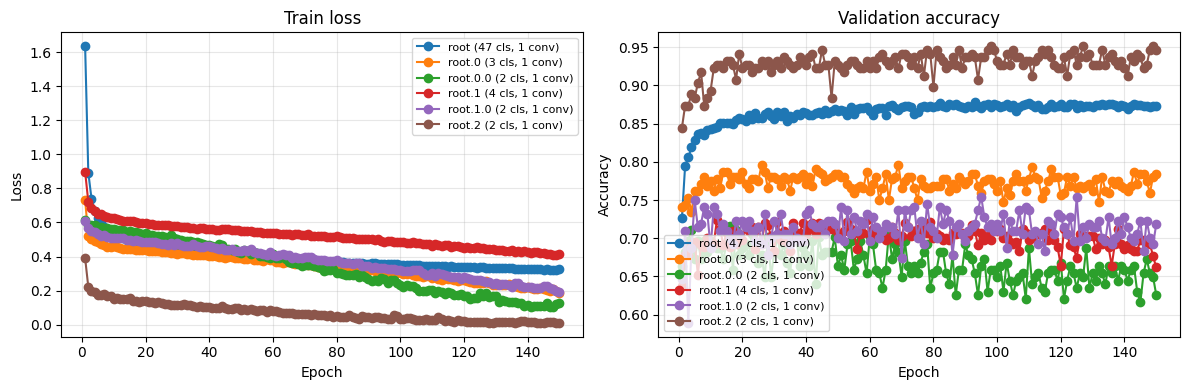

In [6]:
# EMNIST
emnist_model = run_experiment("emnist", emnist_split="balanced", val_size=5000, test_per_class=None,
                              epochs=150, selection_epochs=20, max_depth=10, batch_size=200)

plot_training_curves(emnist_model)


In [22]:
emnist_mmac = compute_mmac_from_loaded_model(emnist_model, (1, 1, 28, 28))
emnist_model.summary['mmac'] = emnist_mmac

with open("emnist_model.pkl", "wb") as f:
    dill.dump(emnist_model, f)

print("EMNIST:")
print(f"MMac: {emnist_mmac:.2f}")

EMNIST:
MMac: 197.74


100%|██████████| 182M/182M [00:05<00:00, 36.2MB/s]
100%|██████████| 64.3M/64.3M [00:03<00:00, 17.6MB/s]


        Testing 1 conv layer(s)...
          Acc: 86.17%, Size: 526.79 KB
        Testing 2 conv layer(s)...
          Acc: 91.20%, Size: 1111.54 KB
    Step 4: Training for 150 epochs...


Training:  10%|█         | 15/150 [05:07<46:12, 20.54s/it, loss=0.5748, train_acc=82.3%, val_acc=85.2%]

          Epoch 15: Train Acc: 82.3%, Val Acc: 85.2%, LR: 0.001000


Training:  20%|██        | 30/150 [10:17<41:34, 20.79s/it, loss=0.5037, train_acc=84.5%, val_acc=86.3%]

...

          Epoch 120: Train Acc: 88.2%, Val Acc: 88.0%, LR: 0.001000


Training:  90%|█████████ | 135/150 [46:58<05:23, 21.55s/it, loss=0.3570, train_acc=88.8%, val_acc=88.1%]

          Epoch 135: Train Acc: 88.8%, Val Acc: 88.1%, LR: 0.001000


Training: 100%|██████████| 150/150 [52:16<00:00, 20.91s/it, loss=0.3486, train_acc=88.9%, val_acc=88.5%]


          Epoch 150: Train Acc: 88.9%, Val Acc: 88.5%, LR: 0.001000
root: classes=10, conv=1, val_acc=0.886
root: 10 classes ['0', '1', '2', '3', '4', '5']...
  root.0: 1 classes ['0']
  root.1: 1 classes ['1']
  root.2: 1 classes ['2']
  root.3: 1 classes ['3']
  root.4: 1 classes ['4']
  root.5: 1 classes ['5']
  root.6: 1 classes ['6']
  root.7: 1 classes ['7']
  root.8: 1 classes ['8']
  root.9: 1 classes ['9']
thop not available. Install with: pip install thop
SVHN test accuracy: 0.871
SVHN test error: 12.91%
SVHN model size: 0.51 MB
SVHN MMac: nan


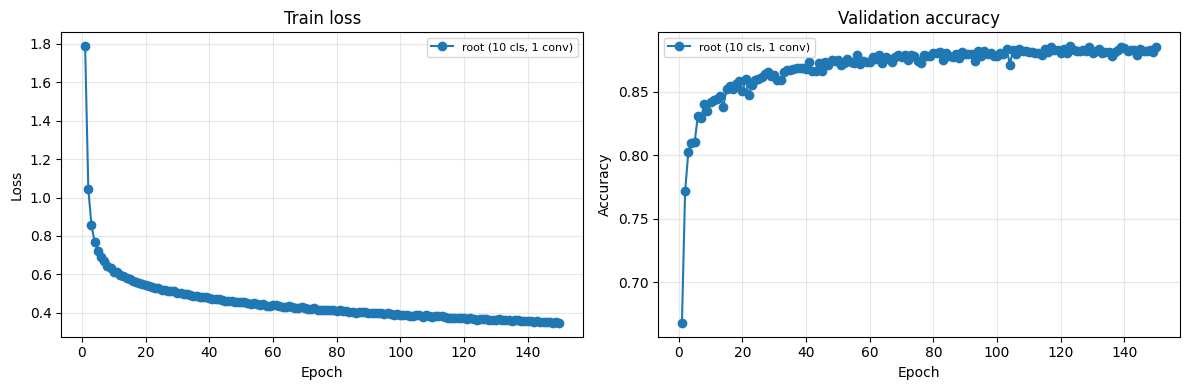

In [23]:
# SVHN
svhn_model = run_experiment("svhn", val_size=6000, test_per_class=None,
                            epochs=150, selection_epochs=20, max_depth=10, batch_size=200)
plot_training_curves(svhn_model)

In [24]:
svhn_mmac = compute_mmac_from_loaded_model(svhn_model, (1, 3, 32, 32))
svhn_model.summary['mmac'] = svhn_mmac

with open("svhn_model.pkl", "wb") as f:
    dill.dump(svhn_model, f)

print("SVHN:")
print(f"MMac: {svhn_mmac:.2f}")

SVHN:
MMac: 9.28


In [ ]:
with open("cifar_model.pkl", "rb") as f:
    cifar_model = dill.load(f)

with open("emnist_model.pkl", "rb") as f:
    emnist_model = dill.load(f)

with open("svhn_model.pkl", "rb") as f:
    svhn_model = dill.load(f)

plot_metric_comparison([cifar_model, emnist_model, svhn_model])